# Gate importance: TN-SHAP-Q vs SVQX (`qshaptools`)

**Standalone notebook.** The TN-SHAP-Q (Owen) and exact-enumeration code is inlined (`numpy` +
`qiskit`); the only external dependency is Heese et al.'s quantum-Shapley toolbox `qshaptools`
([github.com/RaoulHeese/qshaptools](https://github.com/RaoulHeese/qshaptools),
[arXiv:2301.09138](https://arxiv.org/abs/2301.09138)), which we compare against directly.

```bash
git clone https://github.com/RaoulHeese/qshaptools.git
# or set QSHAPTOOLS_PATH to your clone's src/qshaptools
```

**Players = the gates of the circuit.** The gate game removes the gates outside a coalition and reads
the energy $\langle H\rangle$. We reproduce the `qshaptools` README example and compare gate Shapley
values on **accuracy vs. exact enumeration** and on **evaluation count** (Owen extension evaluations
vs. SVQX value evaluations).

`qshaptools` targets Qiskit < 1.0 (`Aer`/`opflow`/`QuantumInstance`, removed in $\geq$ 1.0); this env
is Qiskit 2.x. We run their Shapley **engine verbatim** (`ushap`/`qshap`, pure NumPy) and adapt only
the deprecated circuit glue + a value function computing the identical $\langle H\rangle$.

In [1]:
import os, sys, math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import Statevector, SparsePauliOp, Operator
np.set_printoptions(precision=4, suppress=True)

QSHAPTOOLS_PATH = os.environ.get("QSHAPTOOLS_PATH", "qshaptools/src/qshaptools")
assert os.path.exists(os.path.join(QSHAPTOOLS_PATH, "qshap.py")), (
    f"qshaptools not found at {QSHAPTOOLS_PATH}; git clone it or set QSHAPTOOLS_PATH.")
sys.path.insert(0, QSHAPTOOLS_PATH)
print("qshaptools:", QSHAPTOOLS_PATH)

qshaptools: qshaptools/src/qshaptools


## 1. Adapt the qshaptools circuit glue to Qiskit ≥ 1.0 (Shapley engine untouched)

In [2]:
import tools as qtools
import qshap as qshap_mod

def extract_24(qc, locked_instructions):
    qc_data = []
    for idx, ci in enumerate(qc.data):
        qubits = [qc.find_bit(q).index for q in ci.qubits]
        clbits = [qc.find_bit(c).index for c in ci.clbits]
        opts = {'lock': (locked_instructions is not None and idx in locked_instructions)}
        qc_data.append((ci.operation, qubits, clbits, opts))
    return qc.num_qubits, qc_data

def build_24(qc_data, num_qubits, S=None, cl_bits=False):
    qc = QuantumCircuit(num_qubits, num_qubits if cl_bits else 0)
    for idx, (instr, qubits, clbits, opts) in enumerate(qc_data):
        if S is None or idx in S:
            qc.append(instr, qubits, (clbits if cl_bits else []))
    return qc

qtools.extract_from_circuit = extract_24
qshap_mod.extract_from_circuit = extract_24
qtools.build_circuit = build_24
from qshap import QuantumShapleyValues

def value_energy(qc_data, num_qubits, S, quantum_instance, H):   # identical to their qvalues.value_H
    return float(np.real(Statevector(build_24(qc_data, num_qubits, S)).expectation_value(H)))
print("qshaptools engine ready")

qshaptools engine ready


## 2. Their experiment (qshaptools README): QAOA cost $H=Z_0Z_1+2Z_0-3Z_2$

In [3]:
H = SparsePauliOp.from_list([("ZZI", 1.0), ("ZII", 2.0), ("ZIZ", -3.0)])
qc = QAOAAnsatz(cost_operator=H, reps=1)
for _ in range(3):
    qc = qc.decompose()
qc = qc.assign_parameters([0.3] * len(qc.parameters))
m = len(qc.data)
print(f"{m} gates (players) on {qc.num_qubits} qubits; exact enumeration = 2^{m} = {1<<m} evaluations")

13 gates (players) on 3 qubits; exact enumeration = 2^13 = 8192 evaluations

## 3. TN-SHAP-Q gate Shapley (exact enumeration + Owen)

The gate game $v(S)=\langle H\rangle$ keeps the gates in $S$. It is multilinear in the gate-keep
variables, so its multilinear extension $F(z)$ is evaluated by keeping each gate $i$ with weight
$z_i$, and the Owen integral with $M=\lceil m/2\rceil$ nodes is exact ($2m\lceil m/2\rceil$ extension
evaluations).

In [4]:
def masked_circuit(qc, S):
    new = qc.copy_empty_like()
    for i, ci in enumerate(qc.data):
        if i in S:
            new.append(ci.operation, ci.qubits, ci.clbits)
    return new

def gate_value_table(qc, H):
    m = len(qc.data)
    return {mask: float(np.real(Statevector(masked_circuit(qc, {i for i in range(m) if (mask >> i) & 1}))
                                .expectation_value(H))) for mask in range(1 << m)}

def exact_shapley(tab, n):
    phi = np.zeros(n); fact = [math.factorial(k) for k in range(n+1)]
    for i in range(n):
        others = [j for j in range(n) if j != i]
        for r in range(len(others)+1):
            wgt = fact[r]*fact[n-r-1]/fact[n]
            for S in combinations(others, r):
                mS = 0
                for j in S: mS |= 1 << j
                phi[i] += wgt*(tab[mS | (1 << i)] - tab[mS])
    return phi

def gate_owen_shapley(qc, H, M):
    nq = qc.num_qubits; m = len(qc.data)
    Us = []
    for ci in qc.data:
        q1 = QuantumCircuit(nq); q1.append(ci.operation, ci.qubits); Us.append(Operator(q1).data)
    Hm = Operator(H).data; dim = 1 << nq
    nodes, wts = np.polynomial.legendre.leggauss(M); t = 0.5*(nodes+1); w = 0.5*wts
    def F(z):  # multilinear-extension value: gate i acts with weight z_i
        rho = np.zeros((dim, dim), complex); rho[0, 0] = 1.0
        for gi, U in enumerate(Us):
            p = float(z[gi])
            if p == 1.0: rho = U @ rho @ U.conj().T
            elif p != 0.0: rho = p*(U @ rho @ U.conj().T) + (1-p)*rho
        return float(np.real(np.trace(Hm @ rho)))
    phi = np.zeros(m)
    for i in range(m):
        acc = 0.0
        for tm, wm in zip(t, w):
            z_on = np.full(m, tm); z_on[i] = 1.0
            z_off = np.full(m, tm); z_off[i] = 0.0
            acc += wm*(F(z_on) - F(z_off))
        phi[i] = acc
    return phi, 2*m*M

tab = gate_value_table(qc, H)
phi_exact = exact_shapley(tab, m)
M = (m + 1) // 2
phi_owen, owen_evals = gate_owen_shapley(qc, H, M)
print(f"TN-SHAP-Q Owen M={M}: {owen_evals} extension evaluations; "
      f"max|Owen - exact enum| = {np.max(np.abs(phi_owen-phi_exact)):.2e}")

TN-SHAP-Q Owen M=7: 182 extension evaluations; max|Owen - exact enum| = 4.05e-15


## 4. SVQX gate Shapley via the `qshaptools` engine

`shap_sample_frac=None` is their exact mode (all coalitions); `shap_sample_frac=-K` subsamples $K$
coalitions per player. We count their value-function evaluations (`evaluate_value_only_once` dedups).

In [5]:
def counted(vf):
    st = {"n": 0}
    def w(**kw):
        st["n"] += 1; return vf(**kw)
    return w, st

vf, cnt = counted(value_energy)
qsv = QuantumShapleyValues(qc, value_fun=vf, value_kwargs_dict=dict(H=H), quantum_instance=None,
                           shap_sample_frac=None, evaluate_value_only_once=True, silent=True)
qsv()
phi_their = np.array([qsv.phi_dict[i] for i in sorted(qsv.phi_dict)])
their_exact_q = cnt["n"]
print(f"SVQX exact (qshaptools): {their_exact_q} value evaluations; "
      f"max|SVQX - our enum| = {np.max(np.abs(phi_their-phi_exact)):.2e}")
print(f"\nEXACT-MODE COMPARISON: TN-SHAP-Q Owen {owen_evals} extension evaluations "
      f"vs. SVQX {their_exact_q} value evaluations = {their_exact_q/owen_evals:.0f}x fewer, "
      f"same Shapley vector.")

K_GRID = [1, 2, 4, 8, 16, 32, 64]; SEEDS = 8; sub = []
for K in K_GRID:
    qs, maes = [], []
    for s in range(SEEDS):
        vf, cnt = counted(value_energy)
        q = QuantumShapleyValues(qc, value_fun=vf, value_kwargs_dict=dict(H=H), quantum_instance=None,
                                 shap_sample_frac=-K, evaluate_value_only_once=True,
                                 shap_sample_seed=1000+s, silent=True)
        q()
        phi = np.array([q.phi_dict[i] for i in sorted(q.phi_dict)])
        qs.append(cnt["n"]); maes.append(float(np.mean(np.abs(phi - phi_exact))))
    sub.append((float(np.mean(qs)), float(np.mean(maes)), float(np.std(maes))))
    print(f"  SVQX subsampled K={K:3d}: ~{np.mean(qs):6.0f} value evaluations, MAE={np.mean(maes):.3e}")

SVQX exact (qshaptools): 8192 value evaluations; max|SVQX - our enum| = 3.33e-16

EXACT-MODE COMPARISON: TN-SHAP-Q Owen 182 extension evaluations vs. SVQX 8192 value evaluations = 45x fewer, same Shapley vector.


  SVQX subsampled K=  1: ~    25 value evaluations, MAE=6.570e-01


  SVQX subsampled K=  2: ~    49 value evaluations, MAE=5.228e-01


  SVQX subsampled K=  4: ~    96 value evaluations, MAE=3.755e-01


  SVQX subsampled K=  8: ~   178 value evaluations, MAE=3.128e-01


  SVQX subsampled K= 16: ~   332 value evaluations, MAE=1.992e-01


  SVQX subsampled K= 32: ~   609 value evaluations, MAE=1.503e-01


  SVQX subsampled K= 64: ~  1093 value evaluations, MAE=1.128e-01


## 5. Accuracy vs. evaluation count

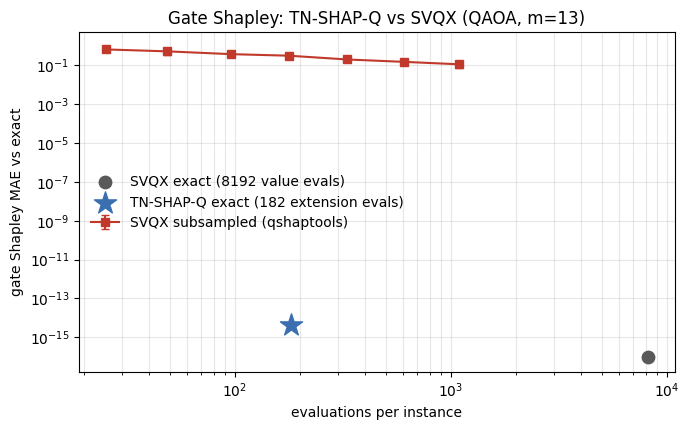

gate Shapley (TN-SHAP-Q): [ 0.6892 -0.0335 -0.2982  0.0448  0.0174  0.1942 -0.0117 -0.1943  0.0863
  0.2873  0.6007  0.4201  0.0104]


In [6]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.errorbar([s[0] for s in sub], [s[1] for s in sub], yerr=[s[2] for s in sub],
            marker="s", capsize=3, color="#c0392b", label="SVQX subsampled (qshaptools)")
ax.scatter([their_exact_q], [1e-16], marker="o", s=80, color="0.35", zorder=5,
           label=f"SVQX exact ({their_exact_q} value evals)")
ax.scatter([owen_evals], [max(np.max(np.abs(phi_owen-phi_exact)), 1e-16)], marker="*", s=280,
           color="#3b6fb0", zorder=6, label=f"TN-SHAP-Q exact ({owen_evals} extension evals)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("evaluations per instance")
ax.set_ylabel("gate Shapley MAE vs exact")
ax.set_title(f"Gate Shapley: TN-SHAP-Q vs SVQX (QAOA, m={m})")
ax.grid(alpha=0.3, which="both"); ax.legend(frameon=False, loc="center left"); fig.tight_layout()
fig.savefig("tnshapq_vs_qshaptools_gates.pdf", bbox_inches="tight")
fig.savefig("tnshapq_vs_qshaptools_gates.png", dpi=150, bbox_inches="tight"); plt.show()
print("gate Shapley (TN-SHAP-Q):", np.round(phi_owen, 4))

## 6. Summary

* **Same answer:** TN-SHAP-Q reproduces the `qshaptools` exact gate Shapley to $\sim10^{-15}$.
* **Fewer evaluations:** TN-SHAP-Q Owen is exact at $2m\lceil m/2\rceil$ extension evaluations vs.
  $2^m$ SVQX value evaluations for the exact mode (here $\approx45\times$ fewer); the SVQX subsampled
  estimator needs far more value evaluations to approach the exact values.

*Caveat:* TN-SHAP-Q evaluates the multilinear extension; SVQX evaluates ordinary masked circuits ---
we compare Shapley outputs and value-evaluation counts.